# Supply Chain Exploratory Data Analysis (EDA)

This notebook performs exploratory data analysis on the cleaned supply chain dataset.

The goal of this analysis is to understand key patterns in the data related to:

- Revenue and profit distribution
- Product performance
- Shipping and delivery efficiency
- Market and regional performance

The insights derived from this analysis will support the development of SQL analytics and Power BI dashboards.

---

## Analysis Workflow

The notebook follows these main steps:

1. Project Introduction
2. Import Libraries
3. Load Dataset
4. Dataset Overview
5. Data Type Preparation
6. Data Structure Validation
7. Feature Engineering
8. Shipping Delay Overview
9. Profitability by Category
10. Category Sales Analysis
11. Category Profit Analysis
12. Regional Sales Analysis
13. Monthly Sales Trend
14. Customer Segment Analysis
15. Shipping Delay Distribution
16. Late Delivery Risk Overview
17. Delivery Delay by Shipping Mode
18. Sales vs Profit by Category
19. Discount Impact on Profitability
20. Key Insights

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

## 2. Load Dataset 
In this step, the cleaned supply chain dataset is loaded into the notebook.  
An initial preview of the data is displayed to understand the structure of the dataset and verify that the data was loaded correctly.

In [2]:
# Load cleaned dataset
df = pd.read_csv("../Python/cleaned_supply_chain_final.csv",
    encoding="utf-8"
)

# Display first rows
df.head()


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Region,Order State,Order Status,Product Card Id,Product Category Id,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,Southeast Asia,Java Occidental,COMPLETE,1360,73,Smart watch,327.75,0,2018-02-03,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,South Asia,Rajastán,PENDING,1360,73,Smart watch,327.75,0,2018-01-18,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,South Asia,Rajastán,CLOSED,1360,73,Smart watch,327.75,0,2018-01-17,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,Oceania,Queensland,COMPLETE,1360,73,Smart watch,327.75,0,2018-01-16,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,Oceania,Queensland,PENDING_PAYMENT,1360,73,Smart watch,327.75,0,2018-01-15,Standard Class


## 3. Dataset Overview
Before performing exploratory analysis, we inspect the dataset structure, size, and data types to better understand the available variables.

In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum().sort_values(ascending=False))

Dataset Shape: (180516, 46)

Column Names:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Id', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Product Card Id', 'Product Category Id', 'Product Name', 'Product Price', 'Product Status', 'shipping date (DateOrders)', 'Shipping Mode']

Data Types:
Type                              object
Days for shi

## 4. Data Type Preparation

Before starting the exploratory analysis, key columns are converted into appropriate data types.

This includes:

- Converting order and shipping dates to datetime format
- Formatting customer zip codes
- Converting selected text columns into categorical variables for more efficient analysis

In [4]:
date_cols = ['order date (DateOrders)', 'shipping date (DateOrders)']

df[date_cols] = df[date_cols].apply(
    lambda s: pd.to_datetime(s, format='%Y-%m-%d', errors='coerce')
)

df['Customer Zipcode'] = df['Customer Zipcode'].astype('Int64').astype(str)

cat_cols = [
    'Type', 'Delivery Status', 'Category Name', 'Customer City', 'Customer Country',
    'Customer Segment', 'Customer State', 'Department Name', 'Market', 'Order City',
    'Order Country', 'Order Region', 'Order State', 'Order Status', 'Product Name', 'Shipping Mode'
]

df[cat_cols] = df[cat_cols].astype('category')

## 5. Data Structure Validation

After converting the data types, the dataset structure is reviewed again to confirm that date, categorical, and other variables are correctly formatted for analysis.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180516 entries, 0 to 180515
Data columns (total 46 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   Type                           180516 non-null  category      
 1   Days for shipping (real)       180516 non-null  int64         
 2   Days for shipment (scheduled)  180516 non-null  int64         
 3   Benefit per order              180516 non-null  float64       
 4   Sales per customer             180516 non-null  float64       
 5   Delivery Status                180516 non-null  category      
 6   Late_delivery_risk             180516 non-null  int64         
 7   Category Id                    180516 non-null  int64         
 8   Category Name                  180516 non-null  category      
 9   Customer City                  180516 non-null  category      
 10  Customer Country               180516 non-null  category      
 11  

## 6. Shipping Performance Feature Engineering

To evaluate delivery performance, new analytical variables are created.

These variables help measure:

- The actual number of shipping days
- The delay compared to the scheduled shipping time
- The order month for time-based analysis

In [6]:
df["actual_shipping_days"] = (
    df["shipping date (DateOrders)"] - df["order date (DateOrders)"]
).dt.days

df["delay_days"] = (
    df["actual_shipping_days"] - df["Days for shipment (scheduled)"]
)

df["order_month"] = df["order date (DateOrders)"].dt.month

## 7. Shipping Delay Overview

This section provides a statistical overview of shipping delays in order to understand the general delivery performance across the dataset.

In [7]:
df["delay_days"].describe()

count    180516.000000
mean          0.565811
std           1.490977
min          -2.000000
25%           0.000000
50%           1.000000
75%           1.000000
max           4.000000
Name: delay_days, dtype: float64

## 8. Profitability by Product Category

The total profit is aggregated by product category to identify which categories contribute the most to overall profitability.

In [8]:
df.groupby("Category Name", observed=True)["Order Profit Per Order"] \
  .sum() \
  .sort_values(ascending=False)

Category Name
Fishing                 756220.767190
Cleats                  494636.919791
Camping & Hiking        427455.568106
Cardio Equipment        383011.098485
Women's Apparel         350421.029567
Water Sports            325146.960038
Indoor/Outdoor Games    318451.430554
Men's Footwear          311902.820214
Shop By Sport           129813.960315
Computers                69656.810171
Electronics              40891.379918
Garden                   33443.010106
Cameras                  30289.799946
Children's Clothing      27118.109595
Crafts                   25531.170060
Women's Clothing         19102.849930
Girls' Apparel           17288.569973
Accessories              16643.520074
Music                    14436.319923
Consumer Electronics     13157.019928
Golf Gloves              12975.490078
Baseball & Softball      12762.130067
Sporting Goods           12518.610119
Golf Shoes               12406.070143
Health and Beauty         9493.629974
Kids' Golf Clubs          9045.83989

## 9. Category Sales Analysis

This section analyzes total sales by product category in order to identify the categories that generate the highest revenue.

The analysis starts by aggregating sales values across categories and then visualizing the top-performing categories.

In [9]:
sales_category = (
    df.groupby("Category Name", observed=True)["Sales"]
    .sum()
    .sort_values(ascending=False)
)

sales_category.head(10)

Category Name
Fishing                 6.929654e+06
Cleats                  4.431943e+06
Camping & Hiking        4.118426e+06
Cardio Equipment        3.694843e+06
Women's Apparel         3.147800e+06
Water Sports            3.113845e+06
Men's Footwear          2.891758e+06
Indoor/Outdoor Games    2.888994e+06
Shop By Sport           1.309522e+06
Computers               6.630000e+05
Name: Sales, dtype: float64

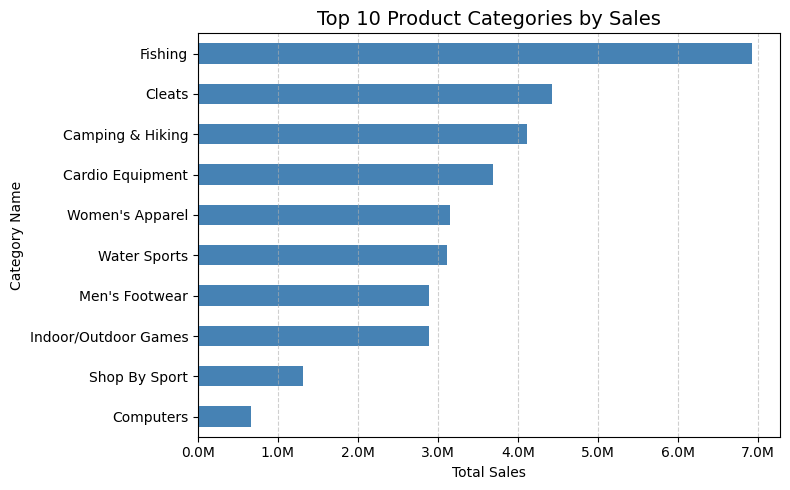

In [10]:
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(8,5))

sales_category.head(10).plot(
    kind="barh",
    ax=ax,
    color="steelblue"
)

ax.set_title("Top 10 Product Categories by Sales", fontsize=14)
ax.set_xlabel("Total Sales")
ax.set_ylabel("Category Name")

ax.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
)

# Grid hinzufügen
ax.grid(axis="x", linestyle="--", alpha=0.6)

# Reihenfolge wie vorher
ax.invert_yaxis()

plt.tight_layout()
plt.show()

## 10. Category Profit Analysis

In addition to revenue, profitability is analyzed across product categories to determine which categories contribute the most to overall profit.

This helps compare revenue performance with actual profit generation.

In [11]:
profit_category = (
    df.groupby("Category Name", observed=True)["Order Profit Per Order"]
    .sum()
    .sort_values(ascending=False)
)

profit_category.head(10)

Category Name
Fishing                 756220.767190
Cleats                  494636.919791
Camping & Hiking        427455.568106
Cardio Equipment        383011.098485
Women's Apparel         350421.029567
Water Sports            325146.960038
Indoor/Outdoor Games    318451.430554
Men's Footwear          311902.820214
Shop By Sport           129813.960315
Computers                69656.810171
Name: Order Profit Per Order, dtype: float64

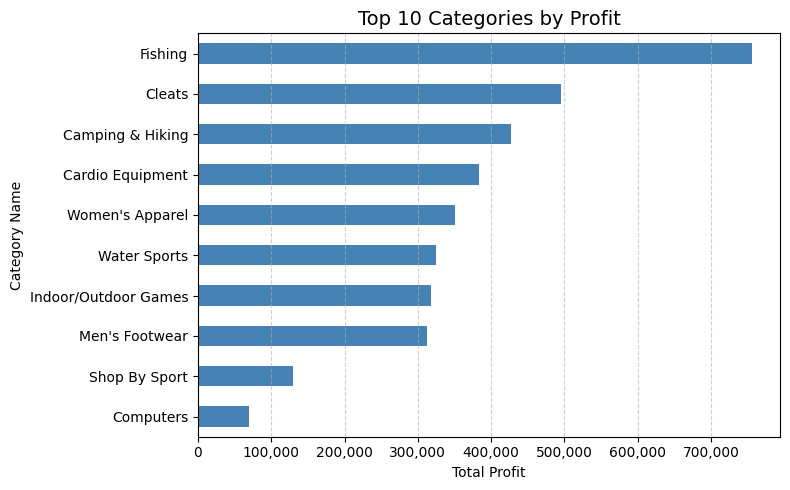

In [12]:
fig, ax = plt.subplots(figsize=(8,5))

profit_category.head(10).plot(
    kind="barh",
    ax=ax,
    color="steelblue"
)

ax.set_title("Top 10 Categories by Profit", fontsize=14)
ax.set_xlabel("Total Profit")
ax.set_ylabel("Category Name")

# Tausenderformat statt wissenschaftlicher Notation
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Rasterlinien
ax.grid(axis="x", linestyle="--", alpha=0.6)

# Reihenfolge beibehalten
ax.invert_yaxis()

plt.tight_layout()
plt.show()

## 11. Regional Sales Analysis

This section analyzes total sales across different order regions to identify which regions contribute the most to overall revenue.

The analysis provides a geographic view of sales performance and helps highlight high-performing regions.

In [13]:
sales_region = (
    df.groupby("Order Region", observed=True)["Sales"]
    .sum()
    .sort_values(ascending=False)
)

sales_region

Order Region
Western Europe     5.894128e+06
Central America    5.665712e+06
South America      2.960881e+06
Northern Europe    2.155474e+06
Southern Europe    2.047919e+06
Oceania            2.016654e+06
Southeast Asia     1.932456e+06
Caribbean          1.651019e+06
West of USA        1.571416e+06
South Asia         1.553681e+06
Eastern Asia       1.486401e+06
East of USA        1.371112e+06
West Asia          1.174672e+06
US Center          1.151356e+06
South of  USA      7.857839e+05
Eastern Europe     7.742666e+05
West Africa        7.279512e+05
North Africa       6.347522e+05
East Africa        3.762349e+05
Central Africa     3.272630e+05
Southern Africa    2.282516e+05
Canada             1.868610e+05
Central Asia       1.098399e+05
Name: Sales, dtype: float64

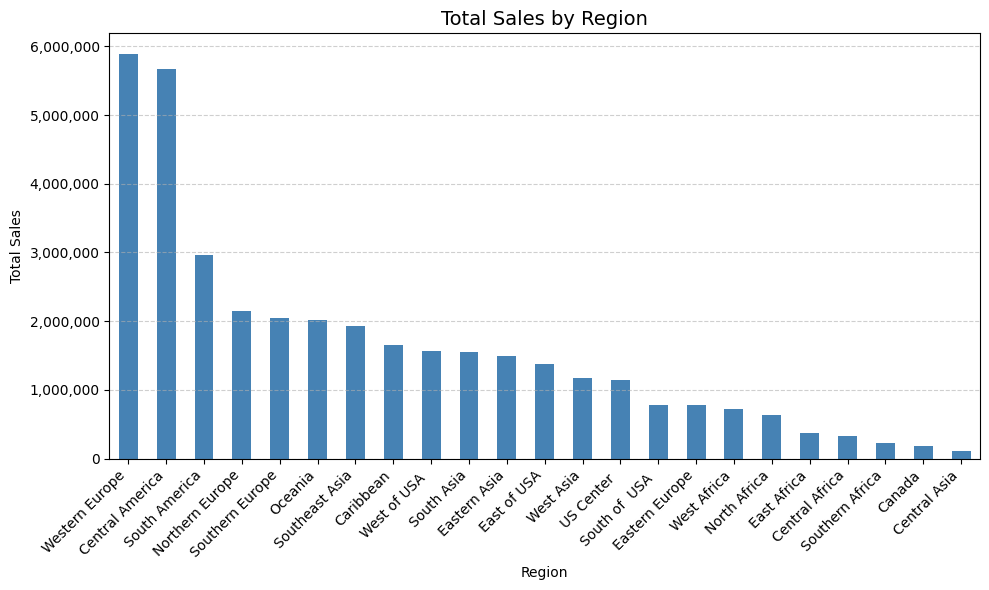

In [14]:
fig, ax = plt.subplots(figsize=(10,6))

sales_region.plot(
    kind="bar",
    ax=ax,
    color="steelblue"
)

ax.set_title("Total Sales by Region", fontsize=14)
ax.set_xlabel("Region")
ax.set_ylabel("Total Sales")

ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
ax.grid(axis="y", linestyle="--", alpha=0.6)

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## 12. Monthly Sales Trend

To understand how sales evolve over time, monthly sales are aggregated based on the order date.

This analysis helps identify trends, seasonality, and changes in revenue over time.

In [15]:
df["order_month"] = df["order date (DateOrders)"].dt.to_period("M")

monthly_sales = df.groupby("order_month")["Sales"].sum()

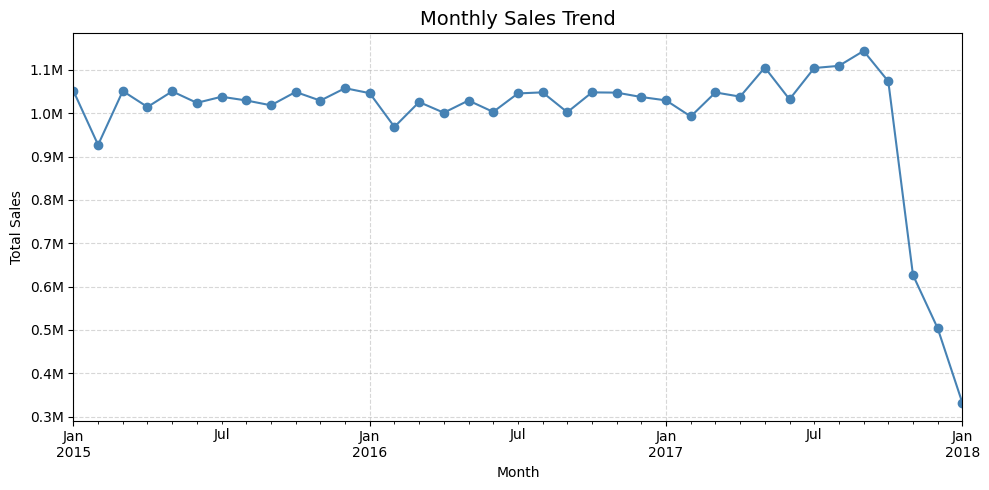

In [16]:

fig, ax = plt.subplots(figsize=(10,5))

monthly_sales.plot(
    ax=ax,
    color="steelblue",
    marker="o"
)

ax.set_title("Monthly Sales Trend", fontsize=14)
ax.set_xlabel("Month")
ax.set_ylabel("Total Sales")

# Sales in Millionen anzeigen
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
)

# Grid
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## 13. Customer Segment Analysis
This section evaluates total sales across customer segments to understand which segments generate the highest revenue.

The analysis supports customer-focused performance evaluation and segmentation insights.

In [17]:
df.groupby("Customer Segment" , observed=True)["Sales"].sum()

Customer Segment
Consumer       1.909518e+07
Corporate      1.116837e+07
Home Office    6.520538e+06
Name: Sales, dtype: float64

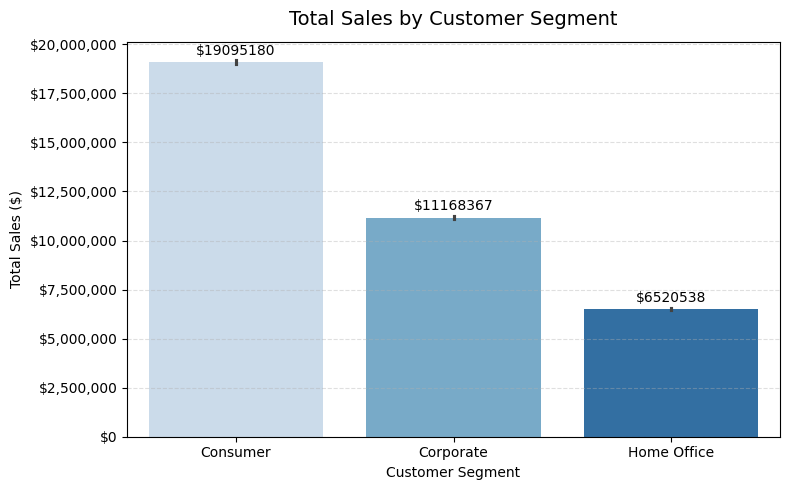

In [18]:
fig, ax = plt.subplots(figsize=(8,5))

sns.barplot(
    x="Customer Segment",
    y="Sales",
    data=df,
    estimator=sum,
    hue="Customer Segment",
    palette="Blues",
    legend=False,
    ax=ax
)

ax.set_title("Total Sales by Customer Segment", fontsize=14, pad=12)
ax.set_xlabel("Customer Segment")
ax.set_ylabel("Total Sales ($)")

# Grid
ax.grid(axis="y", linestyle="--", alpha=0.4)

# Achse als Währung formatieren
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))

# Werte über Balken anzeigen
for container in ax.containers:
    ax.bar_label(container, fmt='$%.0f', padding=3)

plt.tight_layout()
plt.show()

## 14. Shipping Delay Distribution

To better understand delivery performance, shipping delay is calculated as the difference between actual shipping days and scheduled shipping days.

The percentage distribution of delays is then visualized to identify how often orders are delivered on time, early, or late.

In [19]:
df["actual_shipping_days"] = (
    df["shipping date (DateOrders)"] - df["order date (DateOrders)"]
).dt.days

df["delay_days"] = (
    df["actual_shipping_days"] - df["Days for shipment (scheduled)"]
)

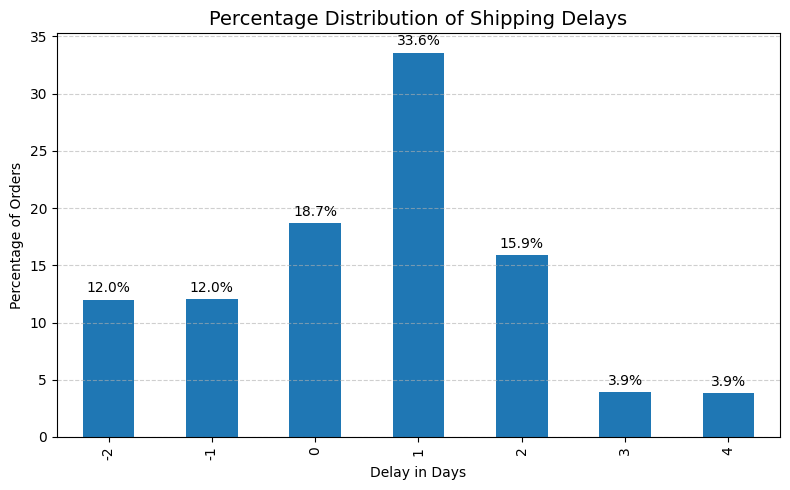

In [20]:
delay_pct = (
    df["delay_days"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

fig, ax = plt.subplots(figsize=(8,5))

delay_pct.plot(kind="bar", ax=ax)

ax.set_title("Percentage Distribution of Shipping Delays", fontsize=14)
ax.set_xlabel("Delay in Days")
ax.set_ylabel("Percentage of Orders")
ax.grid(axis="y", linestyle="--", alpha=0.6)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=3)

plt.tight_layout()
plt.show()

## 15. Late Delivery Risk Overview

This section evaluates the distribution of orders with late delivery risk.

The objective is to understand how frequently orders are exposed to delivery delays and assess the overall operational risk within the supply chain.

In [21]:
df["Late_delivery_risk"].value_counts(normalize=True)

Late_delivery_risk
1    0.548295
0    0.451705
Name: proportion, dtype: float64

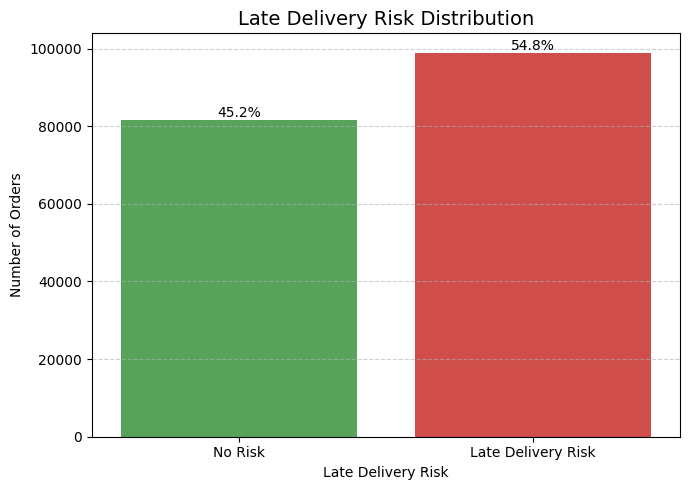

In [22]:
fig, ax = plt.subplots(figsize=(7,5))

sns.countplot(
    x="Late_delivery_risk",
    data=df,
    hue="Late_delivery_risk",
    palette=["#4CAF50", "#E53935"],
    legend=False,
    ax=ax
)

ax.set_title("Late Delivery Risk Distribution", fontsize=14)
ax.set_xlabel("Late Delivery Risk")
ax.set_ylabel("Number of Orders")

ax.set_xticks([0, 1])
ax.set_xticklabels(["No Risk", "Late Delivery Risk"])

ax.grid(axis="y", linestyle="--", alpha=0.6)

# Prozentlabels hinzufügen
total = len(df)

for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(
        percentage,
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

## 16. Regional Late Delivery Risk

To understand whether delivery risk varies geographically, late delivery rates are analyzed by region.

This analysis highlights regions where operational delays occur more frequently.

In [23]:
delay_region = pd.crosstab(
    df["Order Region"],
    df["Late_delivery_risk"]
)

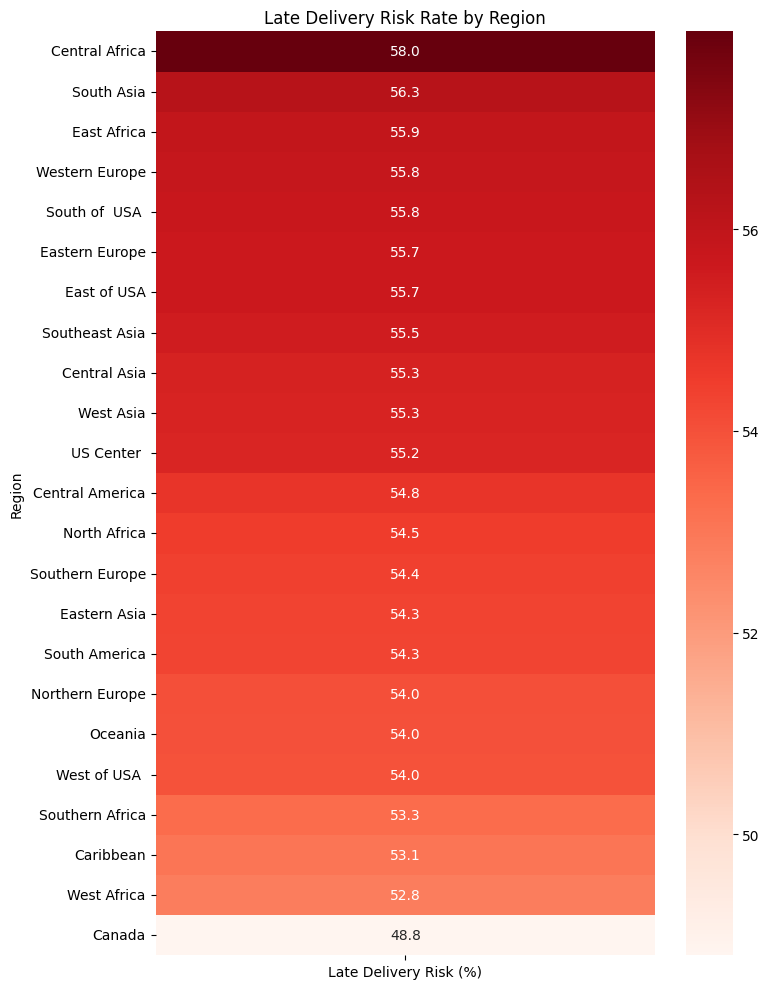

In [24]:
# Anteil Late Delivery Risk = 1 je Region berechnen
delay_region_rate = pd.crosstab(
    df["Order Region"],
    df["Late_delivery_risk"],
    normalize="index"
) * 100

# Nur die Spalte für Risk = 1 behalten
delay_region_rate = delay_region_rate[[1]].sort_values(by=1, ascending=False)
delay_region_rate.columns = ["Late Delivery Risk (%)"]

plt.figure(figsize=(8,10))

sns.heatmap(
    delay_region_rate,
    annot=True,
    fmt=".1f",
    cmap="Reds"
)

plt.title("Late Delivery Risk Rate by Region")
plt.xlabel("")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

## 17. Delivery Delay by Shipping Mode

This section evaluates how shipping modes influence delivery delays.

By comparing delay distributions across shipping methods, it becomes possible to identify which shipping modes tend to deliver faster or experience greater delays.

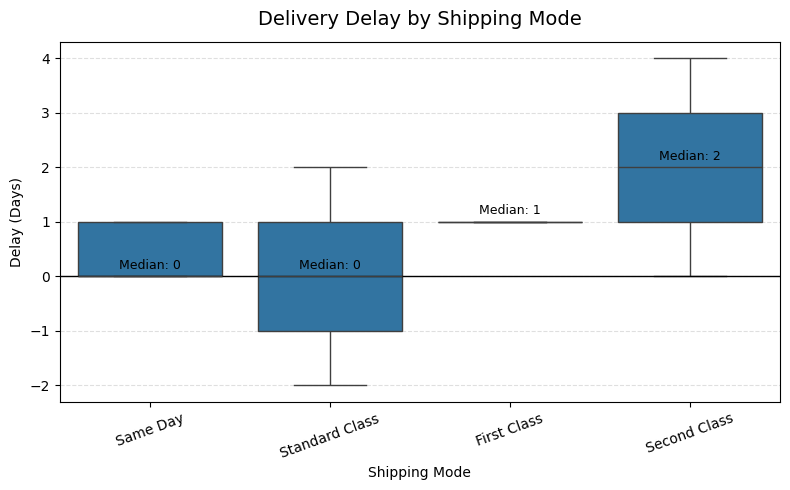

In [25]:
# Define shipping mode order based on median delay
order = df.groupby("Shipping Mode", observed=True )["delay_days"].median().sort_values().index


fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    x="Shipping Mode",
    y="delay_days",
    data=df,
    order=order,
    showfliers=False,
    ax=ax
)

ax.set_title("Delivery Delay by Shipping Mode", fontsize=14, pad=12)
ax.set_xlabel("Shipping Mode")
ax.set_ylabel("Delay (Days)")
ax.axhline(0, color="black", linewidth=1)
ax.grid(axis="y", linestyle="--", alpha=0.4)

medians = df.groupby("Shipping Mode" , observed=True )["delay_days"].median().reindex(order)

for i, mode in enumerate(order):
    ax.text(i, medians[mode] + 0.08, f"Median: {medians[mode]:.0f}",
            ha="center", va="bottom", fontsize=9)

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

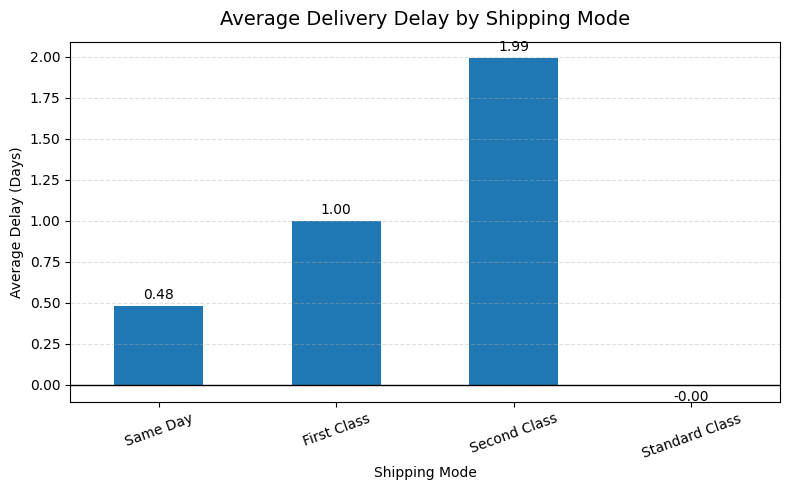

In [26]:
avg_delay = (
    df.groupby("Shipping Mode", observed=True)["delay_days"]
    .mean()
    .reindex(["Same Day", "First Class", "Second Class", "Standard Class"])
)

fig, ax = plt.subplots(figsize=(8, 5))

avg_delay.plot(kind="bar", ax=ax)

ax.set_title("Average Delivery Delay by Shipping Mode", fontsize=14, pad=12)
ax.set_xlabel("Shipping Mode")
ax.set_ylabel("Average Delay (Days)")
ax.axhline(0, color="black", linewidth=1)
ax.grid(axis="y", linestyle="--", alpha=0.4)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 18. Sales vs Profit by Category

To better understand category performance, the relationship between total sales and total profit is analyzed.

This visualization helps identify categories that generate high revenue but may not necessarily produce high profit, highlighting potential margin issues.

In [27]:
category_analysis = (
    df.groupby("Category Name", observed=True)
    .agg(
        total_sales=("Sales", "sum"),
        total_profit=("Order Profit Per Order", "sum")
    )
)

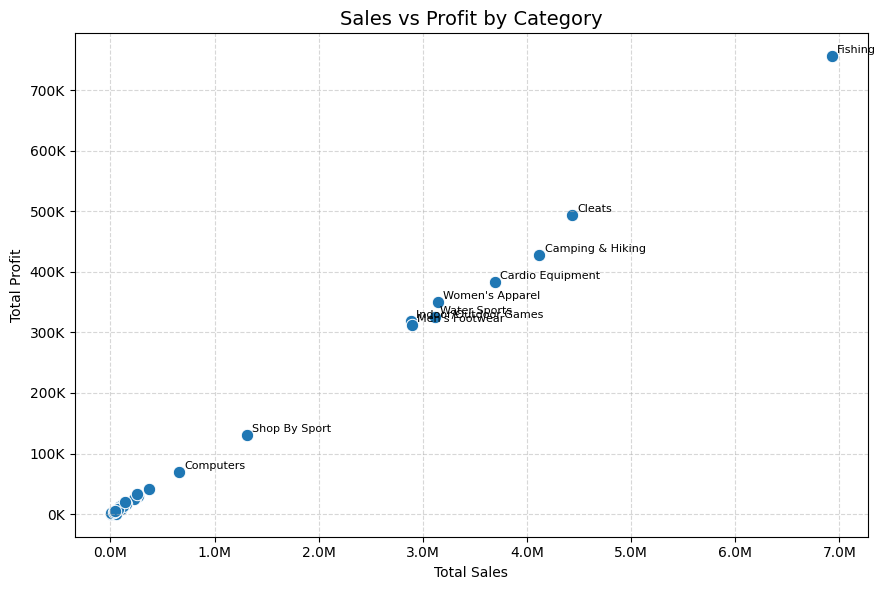

In [28]:
fig, ax = plt.subplots(figsize=(9,6))

sns.scatterplot(
    data=category_analysis,
    x="total_sales",
    y="total_profit",
    s=80,
    ax=ax
)

# Nur Top 10 nach Sales labeln
top10 = category_analysis.sort_values("total_sales", ascending=False).head(10)

for i in top10.index:
    ax.text(
        top10.loc[i, "total_sales"] + 50000,
        top10.loc[i, "total_profit"] + 5000,
        i,
        fontsize=8
    )

ax.set_title("Sales vs Profit by Category", fontsize=14)
ax.set_xlabel("Total Sales")
ax.set_ylabel("Total Profit")

ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f'{y/1e3:.0f}K'))

ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## 19. Impact of High Discounts on Product Profitability

This analysis investigates products that generate the lowest average profit when high discounts are applied.

The objective is to identify products that may become unprofitable under aggressive discount strategies.

In [29]:
# Filter orders with high discount
high_discount = df[df["Order Item Discount"] > 0.3]

In [30]:
worst_profit = (
    high_discount.groupby("Product Name", observed=True)["Order Profit Per Order"]
    .mean()
    .nsmallest(10)
)

### Visualization of the Least Profitable Products

The following chart highlights the products with the lowest average profit when high discounts are applied.

This visualization helps identify products that may become unprofitable under aggressive discount strategies and may require pricing or discount policy adjustments.

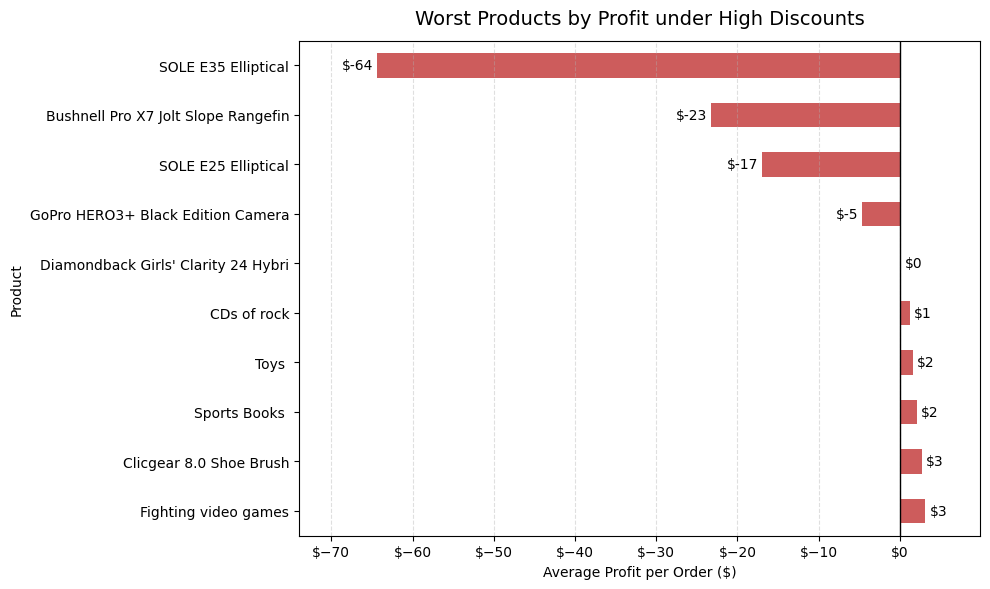

In [31]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

worst_profit_plot = worst_profit.copy()
worst_profit_plot.index = [p[:35] for p in worst_profit_plot.index]

fig, ax = plt.subplots(figsize=(10,6))

worst_profit_plot.plot(
    kind="barh",
    color="indianred",
    ax=ax
)

ax.set_title("Worst Products by Profit under High Discounts", fontsize=14, pad=12)
ax.set_xlabel("Average Profit per Order ($)")
ax.set_ylabel("Product")

# Grid
ax.grid(axis="x", linestyle="--", alpha=0.4)

# Null-Linie
ax.axvline(0, color="black", linewidth=1)

# Achse als Währung
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))

# Werte auf Balken
for container in ax.containers:
    ax.bar_label(container, fmt='$%.0f', padding=3)

# Achse mit Puffer links und rechts
min_val = worst_profit_plot.min()
max_val = worst_profit_plot.max()

padding = (max_val - min_val) * 0.1

ax.set_xlim(min_val * 1.15, max_val + padding)

ax.invert_yaxis()

plt.tight_layout()
plt.show()

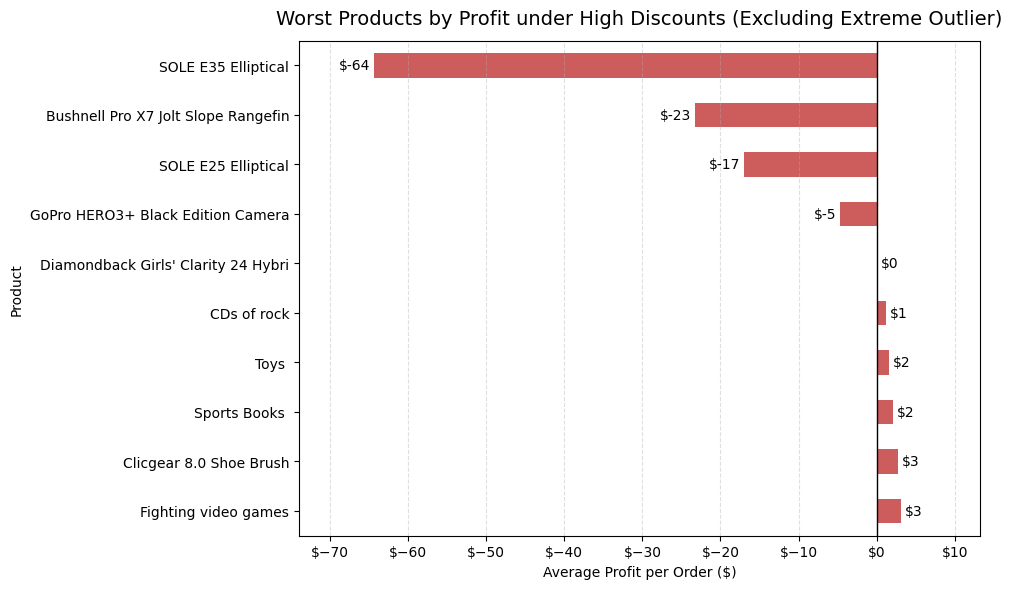

In [32]:
import matplotlib.ticker as ticker

worst_profit_no_outlier = worst_profit[worst_profit > -500].copy()
worst_profit_no_outlier.index = [p[:35] for p in worst_profit_no_outlier.index]

fig, ax = plt.subplots(figsize=(10,6))

worst_profit_no_outlier.plot(
    kind="barh",
    color="indianred",
    ax=ax
)

ax.set_title(
    "Worst Products by Profit under High Discounts (Excluding Extreme Outlier)",
    fontsize=14,
    pad=12
)

ax.set_xlabel("Average Profit per Order ($)")
ax.set_ylabel("Product")

# Grid
ax.grid(axis="x", linestyle="--", alpha=0.4)

# Null-Linie
ax.axvline(0, color="black", linewidth=1)

# Achse als Währung formatieren
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))

# Werte an Balken anzeigen
for container in ax.containers:
    ax.bar_label(container, fmt='$%.0f', padding=3)

# Achsenbereich mit Puffer links und rechts
min_val = worst_profit_no_outlier.min()
max_val = worst_profit_no_outlier.max()

padding = (max_val - min_val) * 0.15

ax.set_xlim(min_val * 1.15, max_val + padding)

ax.invert_yaxis()

plt.tight_layout()
plt.show()

## 20. Key Insights

The exploratory data analysis revealed several important patterns across the supply chain dataset.

### Product and Category Performance
- A small number of product categories generate the majority of total sales.
- However, high sales volumes do not always correspond to high profitability.

### Regional Sales Distribution
- Sales performance varies significantly across regions, indicating geographical differences in demand and market penetration.

### Sales Trends Over Time
- Monthly sales trends show fluctuations, which may reflect seasonal demand patterns or promotional activities.

### Customer Segments
- Certain customer segments contribute disproportionately to overall revenue, highlighting the importance of targeted marketing strategies.

### Delivery Performance
- A noticeable share of orders experiences shipping delays or late delivery risk.
- Delivery performance varies depending on shipping mode and operational conditions.

### Discount Impact
- High discount levels can significantly reduce profitability for certain products.
- Some products become unprofitable when aggressive discount strategies are applied.

These insights provide a foundation for further analytical steps, including SQL-based analytics and interactive dashboards developed in Power BI.